# Module 10 Code Exercise

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display, HTML
import matplotlib.pyplot as plt

sns.set()
%matplotlib inline

token_csv = 'TOKEN2.xls'
lib_csv = 'LIB.xls'
salex_csv = 'salex_nrc.csv'

OHCO = ['author', 'title', 'chap_num', 'para_num', 'sent_num']
CHAPS = ['chap_num']
PARAS = ['chap_num', 'para_num']
SENTS = ['chap_num', 'para_num', 'sent_num']

emo_cols = "anger anticipation disgust fear joy sadness surprise trust polarity".split()
emo = 'polarity'

In [33]:
salex = pd.read_csv(salex_csv).set_index('term_str')
salex.columns = [col.replace('nrc_', '') for col in salex.columns]
salex['polarity'] = salex.positive - salex.negative
salex.head()

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,polarity
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1


In [35]:
TOKEN = pd.read_csv(token_csv)
LIB = pd.read_csv(lib_csv)

TOKENS = TOKEN.merge(LIB, on='book_id', how='left')

In [36]:
TOKENS = TOKENS.merge(salex, left_on='term_str', right_index=True, how='inner')

In [37]:
for col in emo_cols:
    TOKENS[col] = pd.to_numeric(TOKENS[col], errors='coerce')

print(TOKENS[emo_cols].dtypes)

anger           int64
anticipation    int64
disgust         int64
fear            int64
joy             int64
sadness         int64
surprise        int64
trust           int64
polarity        int64
dtype: object


In [38]:
print(TOKENS[['author', 'title', 'book_id']].drop_duplicates().sort_values(['author', 'title']))

           author                                        title  book_id
11         austen                                         Emma      158
161990     austen                                   Lady Susan      946
185250     austen    Love And Freindship And Other Early Works     1212
218636     austen                               Mansfield Park      141
380091     austen                             Northanger Abbey      121
458114     austen                                   Persuasion      105
542255     austen                          Pride and Prejudice     1342
665140     austen                        Sense and Sensibility      161
785809   melville                                Israel Potter    15422
851991   melville   Mardi: and A Voyage Thither, Vol. I (of 2)    13720
949200   melville  Mardi: and A Voyage Thither, Vol. II (of 2)    13721
1051913  melville                      Moby Dick; or The Whale     2701
1269796  melville           Omoo: Adventures in the South Seas  

In [39]:
books = ['Persuasion', 'Moby Dick; or The Whale']

TOKENS_SUB = TOKENS[TOKENS['title'].isin(books)].copy()

print(TOKENS_SUB.shape)
print(TOKENS_SUB[['author', 'title', 'book_id']].drop_duplicates().sort_values(['author', 'title']))

(16818, 25)
           author                    title  book_id
458114     austen               Persuasion      105
1051913  melville  Moby Dick; or The Whale     2701


In [40]:
sent = TOKENS_SUB.groupby('title')[emo_cols].mean()

print(sent)

                            anger  anticipation   disgust      fear       joy  \
title                                                                           
Moby Dick; or The Whale  0.252665      0.284813  0.178306  0.363776  0.294108   
Persuasion               0.159301      0.350226  0.126498  0.230799  0.429189   

                          sadness  surprise     trust  polarity  
title                                                            
Moby Dick; or The Whale  0.289162  0.166198  0.396265 -0.035133  
Persuasion               0.230210  0.215871  0.499705  0.304655  


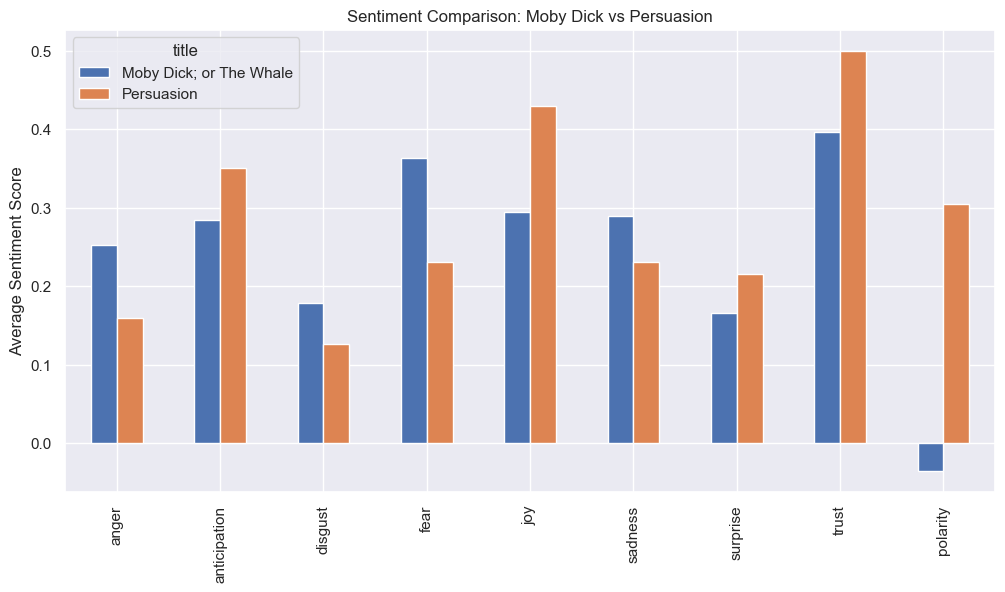

In [41]:
sent.T.plot(kind='bar', figsize=(12,6))
plt.title('Sentiment Comparison: Moby Dick vs Persuasion')
plt.ylabel('Average Sentiment Score')
plt.show()

In [42]:
sent_chaps = (
    TOKENS_SUB
    .groupby(['title'] + CHAPS)[emo_cols]
    .mean()
    .reset_index()
)

In [43]:
def plot_sentiments(df, book_name, emos=['polarity']):
    temp = df[df['title'] == book_name]
    temp.set_index('chap_num')[emos].plot(figsize=(20,5))
    plt.title(f'{book_name} Sentiment by Chapter')
    plt.show()

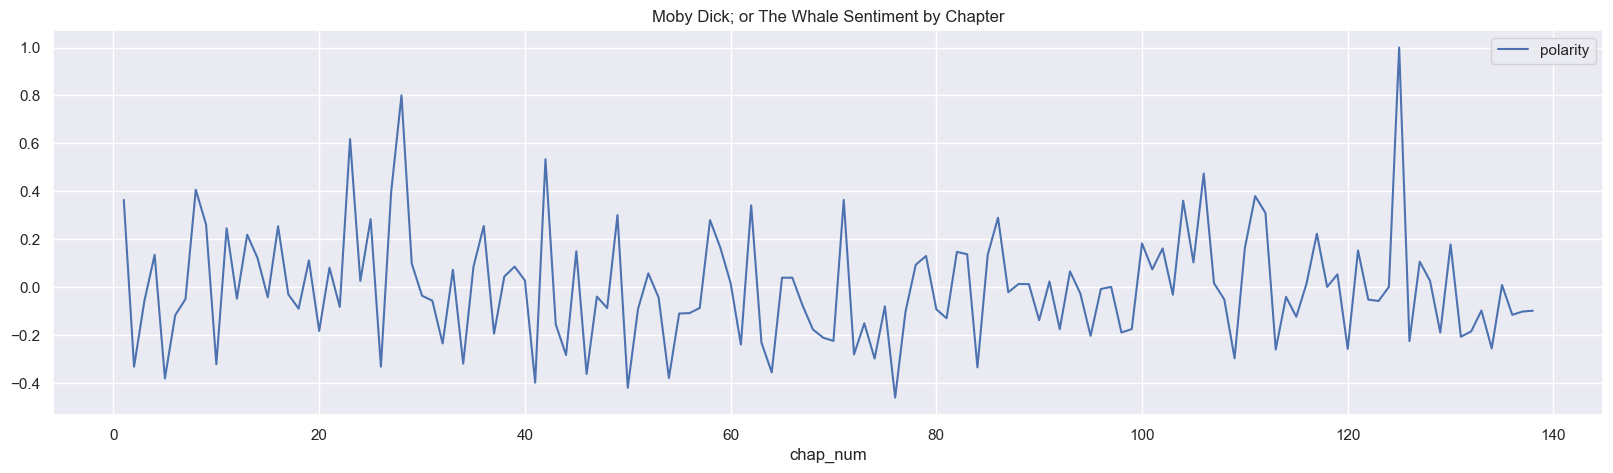

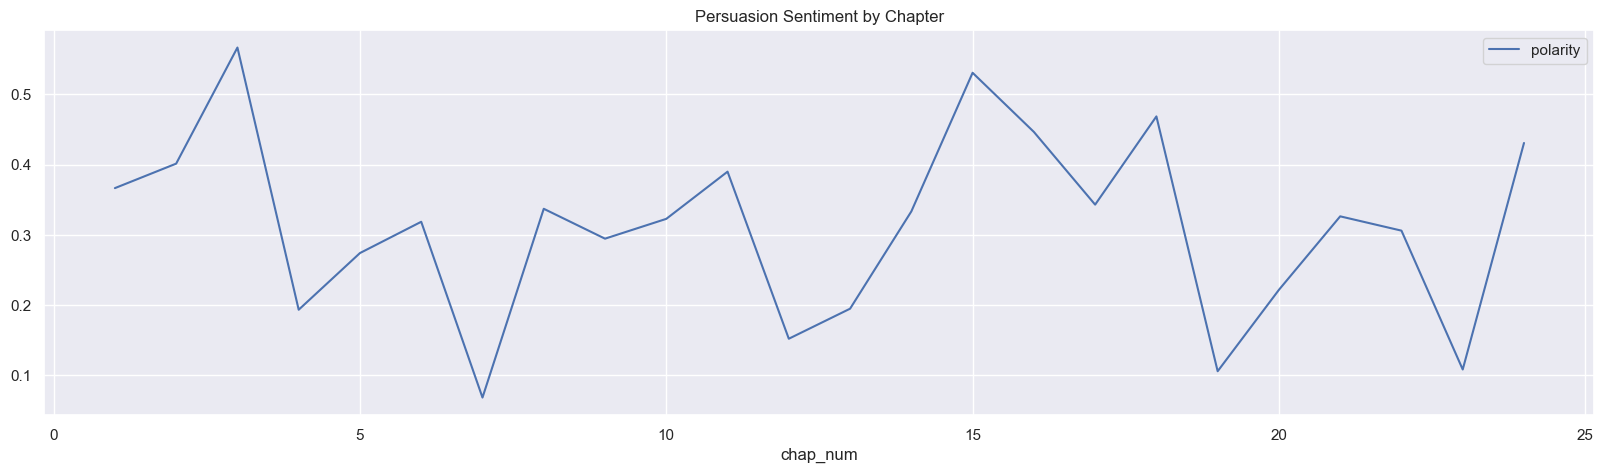

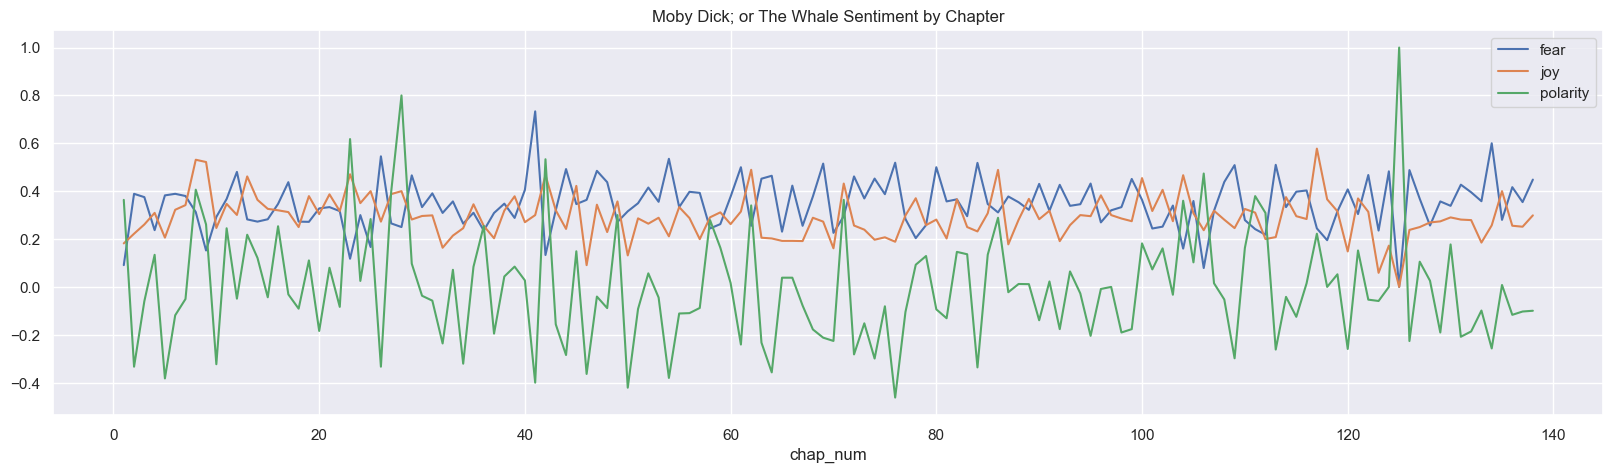

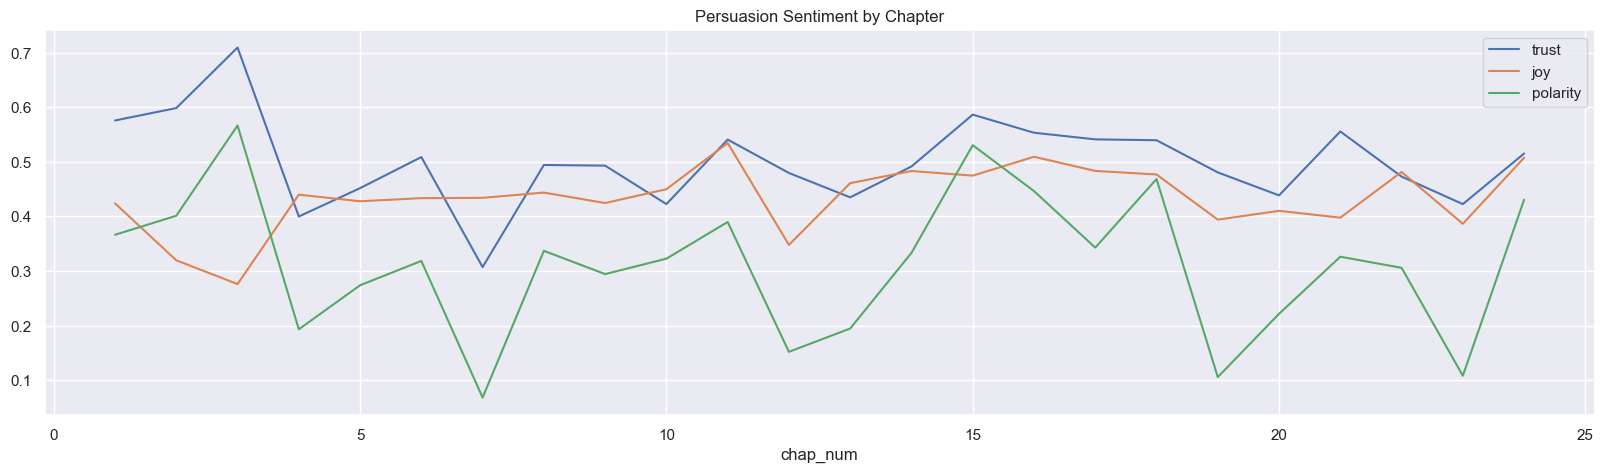

In [44]:
plot_sentiments(sent_chaps, 'Moby Dick; or The Whale', ['polarity'])
plot_sentiments(sent_chaps, 'Persuasion', ['polarity'])

plot_sentiments(sent_chaps, 'Moby Dick; or The Whale', ['fear', 'joy', 'polarity'])
plot_sentiments(sent_chaps, 'Persuasion', ['trust', 'joy', 'polarity'])

In [45]:
TOKENS_SUB['html'] = TOKENS_SUB.apply(
    lambda x: "<span class='sent{}'>{}</span>".format(int(np.sign(x[emo])), x.token_str),
    axis=1
)

In [46]:
sent_sents = (
    TOKENS_SUB
    .groupby(['title'] + SENTS)[emo_cols]
    .mean()
    .reset_index()
)

In [47]:
sent_strings = (
    TOKENS_SUB
    .groupby(['title'] + SENTS)['term_str']
    .apply(lambda x: x.astype(str).str.cat(sep=' '))
    .reset_index(name='sent_str')
)

html_strings = (
    TOKENS_SUB
    .groupby(['title'] + SENTS)['html']
    .apply(lambda x: x.astype(str).str.cat(sep=' '))
    .reset_index(name='html_str')
)

sent_sents = sent_sents.merge(sent_strings, on=['title'] + SENTS, how='left')
sent_sents = sent_sents.merge(html_strings, on=['title'] + SENTS, how='left')

In [48]:
def sample_sentences(df, title_name):
    temp = df[df['title'] == title_name].sample(10, random_state=1)
    rows = []

    for _, row in temp.iterrows():
        valence = round(row[emo], 4)

        if valence > 0:
            color = '#ccffcc'
        elif valence < 0:
            color = '#ffcccc'
        else:
            color = '#f2f2f2'

        idx = f"{row['chap_num']}-{row['para_num']}-{row['sent_num']}"

        rows.append(f"""
        <tr style="background-color:{color};padding:.5rem 1rem;font-size:110%;">
            <td>{valence}</td>
            <td>{idx}</td>
            <td width="600" style="text-align:left;">{row['html_str']}</td>
        </tr>
        """)

    display(HTML('''
    <style>
    #sample1 td{font-size:120%;vertical-align:top;}
    .sent-1{color:red;font-weight:bold;}
    .sent1{color:green;font-weight:bold;}
    </style>
    '''))

    display(HTML(
        '<table id="sample1"><tr><th>Sentiment</th><th>ID</th><th width="600">Sentence</th></tr>'
        + ''.join(rows) +
        '</table>'
    ))

In [49]:
sample_sentences(sent_sents, 'Moby Dick; or The Whale')
sample_sentences(sent_sents, 'Persuasion')

Sentiment,ID,Sentence
-0.3333,76-4-0,battle gash eager
1.0,39-34-1,excited white
1.0,11-5-4,sun
1.0,106-8-2,depth measured
-0.5,10-7-3,despair immovable
0.0,131-7-0,late stranger engaged white
-0.3333,67-24-0,fellow blame wicked
0.0,53-7-1,unaccountable unknown found wreck create excitement
1.0,52-8-5,quiet clean conscience
1.0,21-6-2,good


Sentiment,ID,Sentence
1.0,22-26-1,excellent young
1.0,12-62-1,agreed
0.0,16-17-0,mistaken good
1.0,11-8-2,evident
-1.0,5-12-4,danger
1.0,17-9-7,amusement good
-1.0,5-39-4,illness owing
1.0,5-1-0,Admiral found found opportunity
1.0,4-4-2,confident
0.5,12-68-0,watch lowest evident surprise astonishment convince
